# Dataset Federado Final

**Input:** `bo_vip_clean.csv` + `br_privado_clean.csv`  
**Output:**
- `datasets/federated_dataset_final.csv`
- `proyecto_plus_ti/train_federado.csv` (meses 1–5)
- `proyecto_plus_ti/test_federado_junio.csv` (mes 6)

Se eliminan columnas de identidad bancaria para que el modelo sea agnóstico y pueda generalizar al **Banco 3** (`03_gt_estatal`, sin etiquetas).

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})
sns.set_theme(style='whitegrid')
print('Librerias listas')

Librerias listas


In [2]:
from google.colab import drive
drive.mount('/content/drive')

PATH_DATASETS = '/content/drive/MyDrive/proyecto_plus_ti/datasets/'
PATH_PROJECT  = '/content/drive/MyDrive/proyecto_plus_ti/'
PATH_PLOTS    = PATH_PROJECT + 'plots_nb3/'
os.makedirs(PATH_PLOTS, exist_ok=True)
print(f'PATH: {PATH_DATASETS}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PATH: /content/drive/MyDrive/proyecto_plus_ti/datasets/


In [ ]:
# Cargar datasets limpios (generados en EDA_bo_vip.ipynb y EDA_br_privado.ipynb)
df_bo = pd.read_csv(PATH_DATASETS + 'bo_vip_clean.csv',     low_memory=False)
df_br = pd.read_csv(PATH_DATASETS + 'br_privado_clean.csv', low_memory=False)

print(f'BO VIP    : {df_bo.shape[0]:,} filas | {df_bo.shape[1]} columnas')
print(f'BR Privado: {df_br.shape[0]:,} filas | {df_br.shape[1]} columnas')

diff = set(df_bo.columns).symmetric_difference(set(df_br.columns))
print(f'Diferencia de columnas: {diff if diff else "Ninguna"}')

BO VIP    : 100,003 filas | 50 columnas
BR Privado: 100,000 filas | 50 columnas
Diferencia de columnas: Ninguna


## 1. Comparación entre Datasets

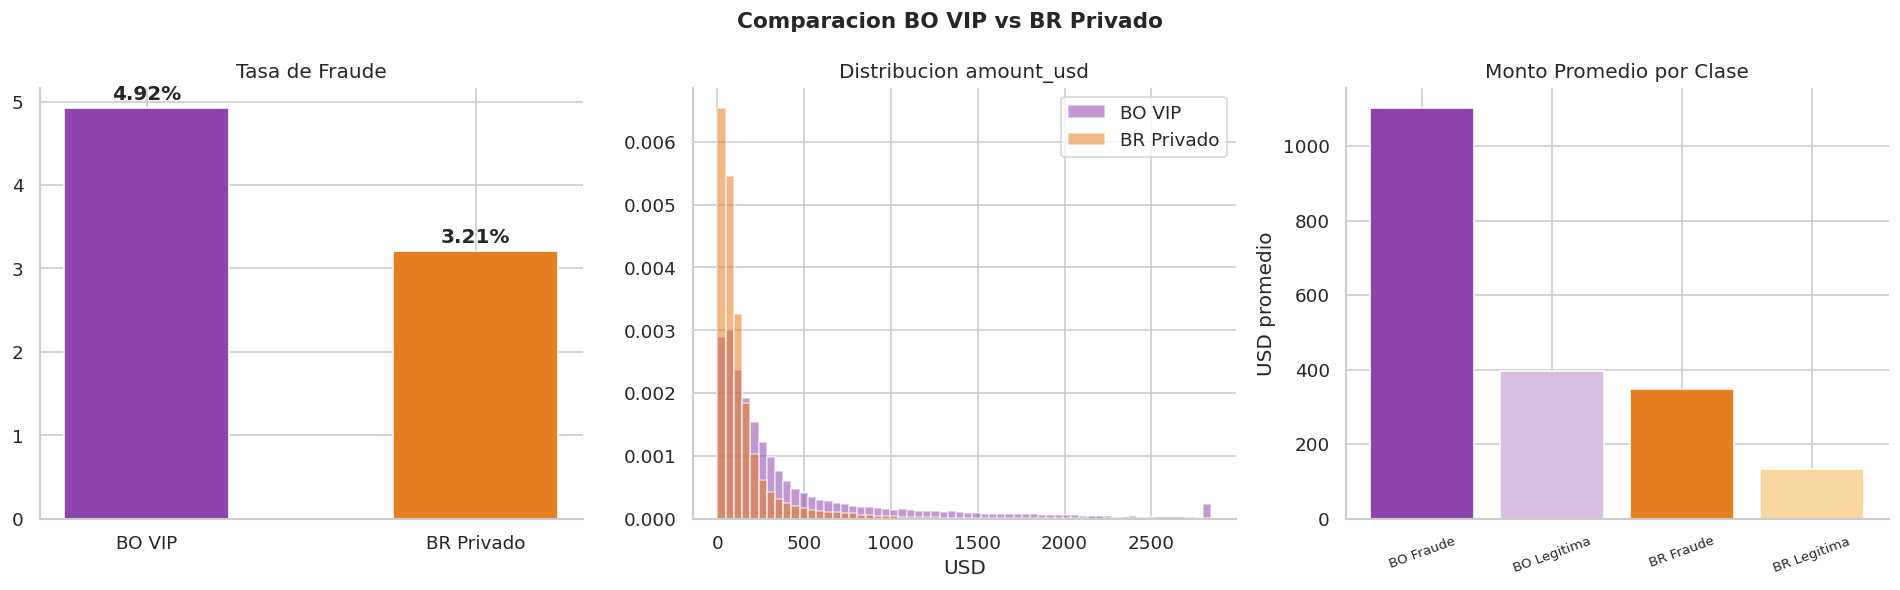

Guardado: 01_comparacion.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Comparacion BO VIP vs BR Privado', fontsize=13, fontweight='bold')
COLORS = {'BO VIP':'#8e44ad','BR Privado':'#e67e22'}

# Tasa de fraude
tasas = {'BO VIP': df_bo['is_fraud'].mean()*100,
         'BR Privado': df_br['is_fraud'].mean()*100}
axes[0].bar(tasas.keys(), tasas.values(),
            color=list(COLORS.values()), width=0.5, edgecolor='white')
for x, v in enumerate(tasas.values()):
    axes[0].text(x, v+0.1, f'{v:.2f}%', ha='center', fontweight='bold')
axes[0].set_title('Tasa de Fraude')
axes[0].spines[['top','right']].set_visible(False)

# Distribución amount_usd
cap = max(df_bo['amount_usd'].quantile(0.99), df_br['amount_usd'].quantile(0.99))
for df, label in [(df_bo,'BO VIP'),(df_br,'BR Privado')]:
    axes[1].hist(df['amount_usd'].clip(upper=cap), bins=60,
                 alpha=0.55, color=COLORS[label], label=label, density=True)
axes[1].set_title('Distribucion amount_usd')
axes[1].set_xlabel('USD'); axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)

# Monto promedio por clase
data = {'BO Fraude':   df_bo.loc[df_bo['is_fraud']==1,'amount_usd'].mean(),
        'BO Legitima': df_bo.loc[df_bo['is_fraud']==0,'amount_usd'].mean(),
        'BR Fraude':   df_br.loc[df_br['is_fraud']==1,'amount_usd'].mean(),
        'BR Legitima': df_br.loc[df_br['is_fraud']==0,'amount_usd'].mean()}
axes[2].bar(data.keys(), data.values(),
            color=['#8e44ad','#d7bde2','#e67e22','#fad7a0'], edgecolor='white')
axes[2].set_title('Monto Promedio por Clase')
axes[2].set_ylabel('USD promedio')
axes[2].tick_params(axis='x', rotation=20, labelsize=8)
axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(PATH_PLOTS+'01_comparacion.png', bbox_inches='tight')
plt.show()
print('Guardado: 01_comparacion.png')

La unión de ambos datasets forma un conjunto diverso con perfiles de fraude complementarios:

**Tasa de fraude:** BO VIP (4.92%) casi duplica a BR Privado (3.21%). El dataset federado promedia **4.06%**, ligeramente ponderado hacia BO VIP por tener 3 fraudes más por cada 1,000 transacciones. El desbalance persiste y deberá manejarse en el modelo.

**Distribución de montos:** Las curvas se solapan en el rango bajo (USD 0–500) pero divergen significativamente en valores altos — BO VIP tiene una cola extendida hasta USD 2,500+ que BR prácticamente no tiene. Esto es esperado: clientes VIP bolivianos tienen tickets promedio mucho más altos.

**Monto promedio por clase:**

| | Fraude | Legítima |
|---|---|---|
| BO VIP | ~USD 1,100 | ~USD 400 |
| BR Privado | ~USD 350 | ~USD 130 |

Aunque los montos absolutos difieren entre bancos, el **patrón relativo se conserva en ambos**: los fraudes tienen en promedio 2.5–3× el monto de una transacción legítima. Esta invarianza justifica que el modelo pueda aprender la señal de monto de forma generalizable, usando `amount_usd` como referencia universal.
## 2. Eliminación de Sesgo Jurisdiccional

Se eliminan columnas que identifican el banco/país para que el modelo sea agnóstico y generalice al Banco 3.

In [5]:
COLS_SESGO = [
    'bank_code','bank_name','bank_country','bank_tier',
    'client_home_city','DE19_acquirer_country_code',
    'DE49_currency_code_transaction','DE50_currency_code_settlement',
    'DE51_currency_code_billing','currency_tx_alpha',
    'DE32_acquiring_institution_id','DE58_authorizing_agent_id',
    'DE100_receiving_institution_id'
]

def quitar_sesgo(df, nombre):
    drop = [c for c in COLS_SESGO if c in df.columns]
    df   = df.drop(columns=drop)
    print(f'[{nombre}] Eliminadas {len(drop)} cols de sesgo | Restantes: {df.shape[1]}')
    return df

df_bo_ns = quitar_sesgo(df_bo, 'BO VIP')
df_br_ns = quitar_sesgo(df_br, 'BR Privado')

rest = [c for c in COLS_SESGO if c in df_bo_ns.columns or c in df_br_ns.columns]
print(f'Sesgo residual: {rest if rest else "Ninguno"}')

[BO VIP] Eliminadas 13 cols de sesgo | Restantes: 37
[BR Privado] Eliminadas 13 cols de sesgo | Restantes: 37
Sesgo residual: Ninguno


## 3. Creación del Dataset Federado

In [6]:
# Interseccion de columnas (compatibilidad con Banco 3)
cols_comunes = sorted(set(df_bo_ns.columns) & set(df_br_ns.columns))
print(f'Columnas en comun: {len(cols_comunes)}')
print(f'Solo BO: {set(df_bo_ns.columns)-set(cols_comunes)}')
print(f'Solo BR: {set(df_br_ns.columns)-set(cols_comunes)}')

# Concatenar y mezclar (seed=42 para reproducibilidad)
df_fed = pd.concat(
    [df_bo_ns[cols_comunes], df_br_ns[cols_comunes]],
    ignore_index=True
)
df_fed = df_fed.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'\nDataset federado: {df_fed.shape[0]:,} filas x {df_fed.shape[1]} columnas')
print(f'Fraude: {df_fed["is_fraud"].mean()*100:.2f}%')
print(f'Meses : {sorted(df_fed["month"].dropna().unique().tolist())}')

Columnas en comun: 37
Solo BO: set()
Solo BR: set()

Dataset federado: 200,003 filas x 37 columnas
Fraude: 4.06%
Meses : [1, 2, 3, 4, 5, 6, 12]


In [7]:
# Verificacion columnas finales
print('Columnas del dataset federado:\n')
for i, col in enumerate(df_fed.columns, 1):
    print(f'  {i:>2}. {col:<45} {str(df_fed[col].dtype):<12} nulos: {df_fed[col].isnull().sum()}')

print('\nEstadisticas amount_usd por clase:')
display(df_fed.groupby('is_fraud')['amount_usd'].describe().round(2))

Columnas del dataset federado:

   1. DE123_pos_data_code                           object       nulos: 0
   2. DE18_merchant_category_code                   int64        nulos: 0
   3. DE22_pos_entry_mode                           int64        nulos: 0
   4. DE23_card_seq_number                          float64      nulos: 0
   5. DE25_pos_condition_code                       int64        nulos: 0
   6. DE39_response_code                            int64        nulos: 0
   7. DE3_processing_code                           int64        nulos: 0
   8. DE43_card_acceptor_name_location              object       nulos: 0
   9. DE4_amount_transaction                        int64        nulos: 0
  10. DE52_pin_data_present                         object       nulos: 0
  11. DE55_emv_data_present                         object       nulos: 0
  12. DE60_pos_terminal_type                        object       nulos: 0
  13. DE61_pos_extended_data                        float64      nulos: 0
  14. 

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,191879.0,263.75,424.91,0.29,51.95,114.87,262.81,6109.47
1,8124.0,803.63,917.35,0.07,211.88,467.75,1031.35,6731.90


## 4. Partición Train / Test

In [8]:
# Test = Junio (mes 6) | Train = Enero-Mayo (meses 1-5)
if df_fed['month'].between(1,12).any():
    mask_train = df_fed['month'].between(1, 5)
    mask_test  = df_fed['month'] == 6
else:
    n = int(len(df_fed)/6)
    mask_test  = pd.Series([False]*len(df_fed)); mask_test.iloc[-n:] = True
    mask_train = ~mask_test
    print('AVISO: split posicional (month no disponible)')

df_train = df_fed[mask_train].reset_index(drop=True)
df_test  = df_fed[mask_test].reset_index(drop=True)

print(f'Train (meses 1-5): {df_train.shape[0]:,} filas | '
      f'Fraude: {df_train["is_fraud"].mean()*100:.2f}%')
print(f'Test  (junio)    : {df_test.shape[0]:,} filas | '
      f'Fraude: {df_test["is_fraud"].mean()*100:.2f}%')

Train (meses 1-5): 167,778 filas | Fraude: 4.10%
Test  (junio)    : 32,055 filas | Fraude: 3.90%


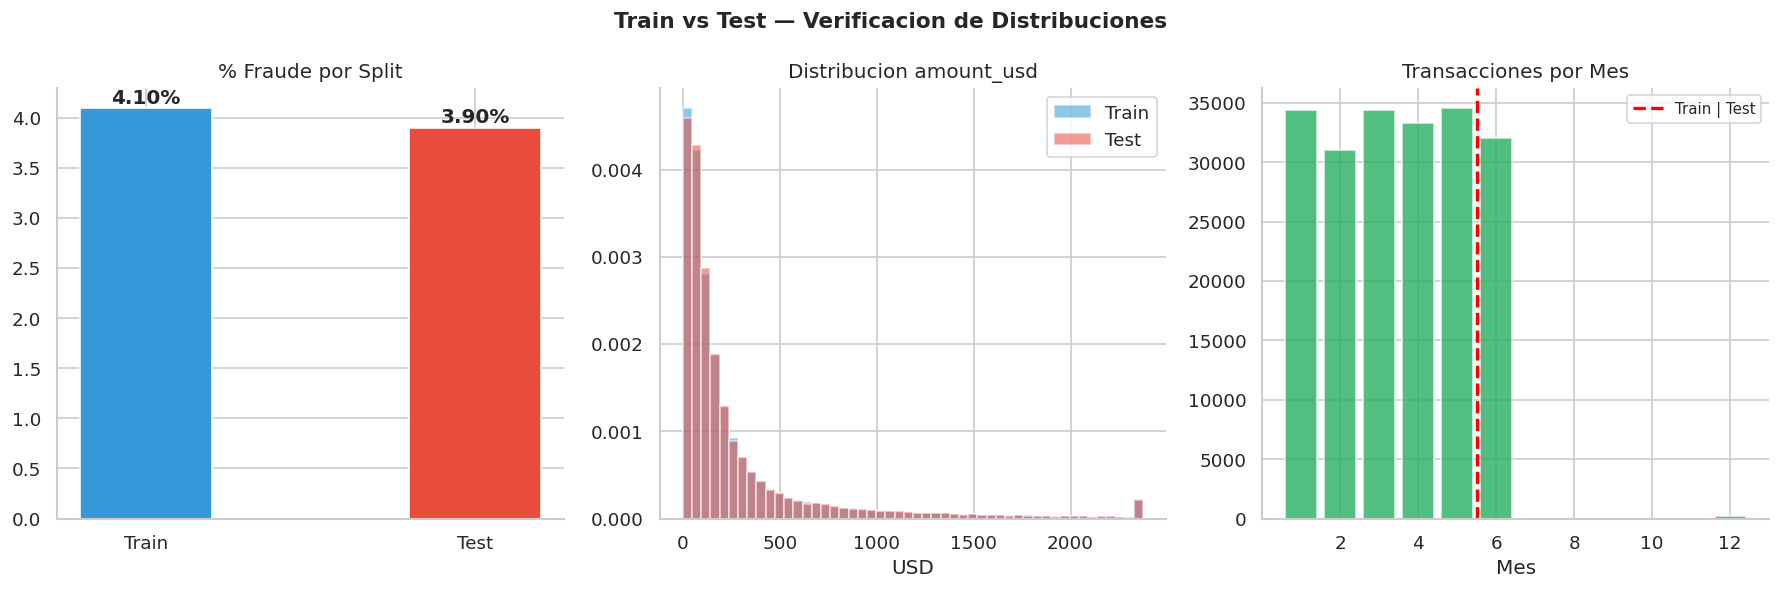

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Train vs Test — Verificacion de Distribuciones', fontsize=13, fontweight='bold')

# % fraude por split
splits = {'Train': df_train['is_fraud'].mean()*100,
          'Test':  df_test['is_fraud'].mean()*100}
axes[0].bar(splits.keys(), splits.values(),
            color=['#3498db','#e74c3c'], width=0.4)
for x, v in enumerate(splits.values()):
    axes[0].text(x, v+0.05, f'{v:.2f}%', ha='center', fontweight='bold')
axes[0].set_title('% Fraude por Split')
axes[0].spines[['top','right']].set_visible(False)

# amount_usd
cap = df_fed['amount_usd'].quantile(0.99)
for df_s, lbl, color in [(df_train,'Train','#3498db'),(df_test,'Test','#e74c3c')]:
    axes[1].hist(df_s['amount_usd'].clip(upper=cap), bins=50,
                 alpha=0.55, color=color, label=lbl, density=True)
axes[1].set_title('Distribucion amount_usd')
axes[1].set_xlabel('USD'); axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)

# Transacciones por mes
mes_cnt = df_fed.groupby('month')['is_fraud'].count()
axes[2].bar(mes_cnt.index, mes_cnt.values, color='#27ae60', alpha=0.8, edgecolor='white')
axes[2].axvline(5.5, color='red', ls='--', lw=2, label='Train | Test')
axes[2].set_title('Transacciones por Mes'); axes[2].set_xlabel('Mes')
axes[2].legend(fontsize=9)
axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(PATH_PLOTS+'02_train_test.png', bbox_inches='tight')
plt.show()

### Verificación de la Partición Train / Test

La partición temporal produce splits estadísticamente consistentes:

| Partición | Filas | % Fraude | Meses |
|---|---|---|---|
| **Train** | 167,778 | 4.10% | Enero – Mayo |
| **Test** | 32,055 | 3.90% | Junio |

**% Fraude:** La diferencia de 0.2 puntos porcentuales entre Train y Test es mínima, indicando que la tasa de fraude es estable en el tiempo — no hay concept drift significativo entre los primeros 5 meses y junio. El modelo no estará en desventaja al evaluar en test.

**Distribución de montos:** Las curvas de Train y Test son prácticamente idénticas, confirmando que junio no tiene un perfil de transacciones atípico. La partición es representativa.

**Transacciones por mes:** Los volúmenes mensuales son uniformes (~31,000–34,000 por mes en train). El pequeño bar en mes 12 corresponde al artefacto del generador sintético (~170 filas totales entre ambos bancos), que queda fuera de ambas particiones automáticamente al no ser mes 1–6.

> El test de junio **no debe usarse para ninguna decisión de modelado** — queda reservado como evaluación final del modelo federado sobre datos que nunca habrá visto.
## 5. Guardar Outputs

In [10]:
FED_PATH   = PATH_DATASETS + 'federated_dataset_final.csv'
TRAIN_PATH = PATH_PROJECT  + 'train_federado.csv'
TEST_PATH  = PATH_PROJECT  + 'test_federado_junio.csv'

df_fed.to_csv(FED_PATH,    index=False)
df_train.to_csv(TRAIN_PATH, index=False)
df_test.to_csv(TEST_PATH,   index=False)

print('Archivos guardados:')
print(f'  {FED_PATH}')
print(f'  {TRAIN_PATH}')
print(f'  {TEST_PATH}')

print(f'\nRESUMEN FINAL')
print(f'  Dataset federado  : {df_fed.shape[0]:,} filas x {df_fed.shape[1]} columnas')
print(f'  Train (meses 1-5) : {df_train.shape[0]:,} filas | '
      f'{df_train["is_fraud"].mean()*100:.2f}% fraude')
print(f'  Test  (junio)     : {df_test.shape[0]:,} filas | '
      f'{df_test["is_fraud"].mean()*100:.2f}% fraude')
print(f'  Sesgo eliminado   : {len(COLS_SESGO)} columnas')
print(f'  Features nuevas   : time_since_last_txn_min, txn_count_1h/24h, amount_zscore')

Archivos guardados:
  /content/drive/MyDrive/proyecto_plus_ti/datasets/federated_dataset_final.csv
  /content/drive/MyDrive/proyecto_plus_ti/train_federado.csv
  /content/drive/MyDrive/proyecto_plus_ti/test_federado_junio.csv

RESUMEN FINAL
  Dataset federado  : 200,003 filas x 37 columnas
  Train (meses 1-5) : 167,778 filas | 4.10% fraude
  Test  (junio)     : 32,055 filas | 3.90% fraude
  Sesgo eliminado   : 13 columnas
  Features nuevas   : time_since_last_txn_min, txn_count_1h/24h, amount_zscore


## Resumen Dataset Federado Final

### ¿Qué se hizo?

Se unificaron los datasets limpios de Banco 1 (BO VIP) y Banco 2 (BR Privado) en un único dataset federado, diseñado para entrenar un modelo que pueda **generalizar al Banco 3 (GT Estatal, sin etiquetas)**.

### Columnas eliminadas por sesgo jurisdiccional (50 → 37)

Se eliminaron 13 columnas que identifican de forma directa el banco o país de origen:

| Tipo | Columnas eliminadas |
|---|---|
| **Identidad bancaria** | `bank_code`, `bank_name`, `bank_country`, `bank_tier` |
| **Ubicación del cliente** | `client_home_city` |
| **País del adquiriente** | `DE19_acquirer_country_code` |
| **Monedas locales** | `DE49_currency_code_transaction`, `DE50_currency_code_settlement`, `DE51_currency_code_billing`, `currency_tx_alpha` |
| **Instituciones específicas** | `DE32_acquiring_institution_id`, `DE58_authorizing_agent_id`, `DE100_receiving_institution_id` |

**¿Por qué?** Si el modelo aprende que `bank_country = BO` → fraude 4.92% y `bank_country = BR` → fraude 3.21%, simplemente memorizará el banco en lugar de aprender patrones de comportamiento. Al eliminar estas columnas, el modelo debe aprender señales transaccionales universales (montos, distancia, hora, velocidad) que sean válidas para cualquier banco, incluido Banco 3.

### Construcción del dataset federado

1. **Intersección de columnas:** Se usaron las 37 columnas presentes en ambos datasets limpios — garantiza compatibilidad estructural con Banco 3, que tiene la misma estructura ISO 8583.
2. **Concatenación:** 100,003 (BO) + 100,000 (BR) = **200,003 filas**.
3. **Shuffle aleatorio** con `random_state=42` para que el modelo no aprenda el orden banco 1 → banco 2 durante el entrenamiento.
4. **Cero nulos residuales** — heredado del preprocesamiento de NB1 y NB2.

### Partición temporal Train / Test

| | Filas | % Fraude | Uso |
|---|---|---|---|
| **Train** (meses 1–5) | 167,778 | 4.10% | Entrenamiento + validación del modelo |
| **Test** (junio) | 32,055 | 3.90% | Evaluación final — reservado |

Se eligió una **partición temporal** (no aleatoria) porque refleja el escenario real: el modelo se entrena con histórico y se evalúa en datos futuros que nunca vio. Una partición aleatoria inflaría artificialmente las métricas al mezclar meses.

### Outputs generados

| Archivo | Destino | Descripción |
|---|---|---|
| `federated_dataset_final.csv` | `datasets/` | Dataset completo (200,003 × 37) |
| `train_federado.csv` | `proyecto_plus_ti/` | Meses 1–5 para entrenamiento |
| `test_federado_junio.csv` | `proyecto_plus_ti/` | Junio — evaluación final |

### Próximo paso
**Notebook 4:** Entrenamiento del modelo federado (LightGBM/XGBoost) sobre `train_federado.csv`, con la función `feval` personalizada de **Maximizar Monto Salvado**, y evaluación final sobre `test_federado_junio.csv`.